# Experiment 1: Baseline GPT (non-reversible)

**Objective.** Train a ~20M-parameter GPT on 50M TinyStories tokens with standard
backpropagation, to serve as the non-reversible reference for the reversibility
experiments.

**Hypothesis.** A standard stack retains every intermediate activation for the
backward pass, so peak memory grows with depth and limits the batch size that
fits on the device.

**Procedure.**
- Train at the shared equal-batch anchor `B_FIXED = 196`.
- Probe the largest batch the standard stack can run, then train a second run at
  that maximum.
- Measure peak memory, throughput, final loss, and a parameter / stack / head
  memory breakdown.

**Reference.** Gal, Eliasof, Turek, Ascher, Treister, Haber. *Reversing Large Language Models for Efficient Training and Fine-Tuning.* arXiv:2512.02056. https://arxiv.org/abs/2512.02056

## Environment setup

The runtime dependencies are installed and the environment is printed, so the
torch/CUDA versions are captured in the notebook output.

In [1]:
!pip install -q torch datasets transformers tqdm matplotlib

import torch
print("torch", torch.__version__, "| cuda", torch.version.cuda,
      "| mps", torch.backends.mps.is_available())


torch 2.11.0+cu128 | cuda 12.8 | mps False


## 1. Data preparation

The TinyStories corpus is tokenized with the GPT-2 BPE tokenizer and written to
raw `uint16` shards (`data/train.bin`, `data/val.bin`). An `EOT` token (50256) is
inserted between stories. Tokenization is streamed and multi-threaded to keep
host RAM low, and is skipped if the shards already exist.

In [2]:
import os

# Disable the tokenizer's own internal threads so parallelism is driven by the
# ThreadPoolExecutor below (avoids oversubscription and works on Colab + local).
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from array import array
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer

EOT = 50256  # <|endoftext|> separator between stories


def _enough(path, need):
    return os.path.exists(path) and os.path.getsize(path) >= need * 2


def _write(ds, tok, path, max_tokens, encode_batch=2000, num_threads=None):
    """Tokenize in parallel across threads, streaming the dataset (low RAM)."""
    if num_threads is None:
        num_threads = os.cpu_count() or 4

    def encode(texts):
        ids = array("H")  # uint16 accumulator (compact 2B/token)
        for enc in tok(texts, add_special_tokens=False)["input_ids"]:
            ids.extend(enc)
            ids.append(EOT)
        return ids

    buf = array("H")
    window = num_threads * 2
    pbar = tqdm(total=max_tokens, desc=f"Tokenizing {os.path.basename(path)}")

    batches = ds.iter(batch_size=encode_batch)
    with ThreadPoolExecutor(max_workers=num_threads) as ex:
        while len(buf) < max_tokens:
            futs = []
            for _ in range(window):
                try:
                    batch = next(batches)
                except StopIteration:
                    break
                futs.append(ex.submit(encode, batch["text"]))
            if not futs:
                break
            for f in futs:
                res = f.result()
                buf.extend(res)
                pbar.update(len(res))
    pbar.close()

    buf = buf[:max_tokens]
    with open(path, "wb") as f:
        buf.tofile(f)  # raw uint16 bytes
    print(f"Wrote {len(buf):,} tokens to {path}")


def prepare_data(data_dir="data", train_tokens=51_000_000, val_tokens=1_000_000,
                 encode_batch=2000, num_threads=None):
    os.makedirs(data_dir, exist_ok=True)
    train_path = os.path.join(data_dir, "train.bin")
    val_path = os.path.join(data_dir, "val.bin")

    tok = AutoTokenizer.from_pretrained("gpt2")

    if not _enough(train_path, train_tokens):
        print("Loading TinyStories train...")
        ds = load_dataset("roneneldan/TinyStories", split="train")
        _write(ds, tok, train_path, train_tokens, encode_batch, num_threads)
    else:
        print("train.bin already prepared.")

    if not _enough(val_path, val_tokens):
        print("Loading TinyStories validation...")
        ds = load_dataset("roneneldan/TinyStories", split="validation")
        _write(ds, tok, val_path, val_tokens, encode_batch, num_threads)
    else:
        print("val.bin already prepared.")

    return train_path, val_path


prepare_data(data_dir="data", train_tokens=51_000_000, val_tokens=1_000_000)
print("Data ready.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Tokenizing train.bin:   0%|          | 0/51000000 [00:00<?, ?it/s][transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1049 > 1024). Running this sequence through the model will result in indexing errors
Tokenizing train.bin: 54119384it [00:29, 1826943.86it/s]


Wrote 51,000,000 tokens to data/train.bin
Loading TinyStories validation...


Tokenizing val.bin: 4765918it [00:02, 2034881.46it/s]                           

Wrote 1,000,000 tokens to data/val.bin
Data ready.


## 2. Training harness and metrics

Shared constants and helpers: device selection (`cuda → mps → cpu`), seeding,
batch construction from the memory-mapped shards, the cosine LR schedule, the
validation routine (a fixed `VAL_SEED` draws identical windows at every
evaluation), peak-memory sampling, and the `train()` loop. Determinism is
requested best-effort via `cudnn.deterministic`.

In [3]:
import math
import os
import resource
import sys
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Local Mac only: cap MPS so Metal doesn't over-commit and swap.
if not any(k in os.environ for k in ("COLAB_RELEASE_TAG", "COLAB_GPU")):
    os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "1.0")
    os.environ.setdefault("PYTORCH_MPS_LOW_WATERMARK_RATIO", "0.9")

# Device selection: CUDA -> MPS (Apple Silicon) -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

# Best-effort determinism (GPU reductions may still differ).
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# --- Shared protocol constants (identical in all four notebooks) ---
SEED = 1337
VAL_SEED = 20250925        # separate, fixed RNG for validation draws
B_FIXED = 196              # fixed equal-batch anchor for baseline + reversible
BLOCK_SIZE = 512
TOKENS = 50_000_000
CE_CHUNKS = 8              # vocab head is chunked + checkpointed (see model cell)
USE_AMP = True
LR = 6e-4


@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 512
    n_embd: int = 256
    n_head: int = 8
    n_layer: int = 9
    dropout: float = 0.0


def load_data(data_dir="data"):
    train_arr = np.memmap(os.path.join(data_dir, "train.bin"), dtype=np.uint16, mode="r")
    val_arr = np.memmap(os.path.join(data_dir, "val.bin"), dtype=np.uint16, mode="r")
    return train_arr, val_arr


def get_batch(arr, B, T, rng, device):
    n = len(arr) - T - 1
    ix = rng.integers(0, n, size=B)
    x = np.stack([np.asarray(arr[i:i + T], dtype=np.int64) for i in ix])
    y = np.stack([np.asarray(arr[i + 1:i + T + 1], dtype=np.int64) for i in ix])
    return torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)


class PeakMem:
    def __init__(self, device):
        self.device = device
        self.peak = 0.0
        if device.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        elif device.type == "mps":
            torch.mps.empty_cache()

    def sample(self):
        if self.device.type == "cuda":
            self.peak = torch.cuda.max_memory_allocated() / 1e6
        elif self.device.type == "mps":
            self.peak = max(self.peak, torch.mps.current_allocated_memory() / 1e6)
        else:
            raw = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            mb = raw / 1e6 if sys.platform == "darwin" else raw / 1e3
            self.peak = max(self.peak, mb)
        return self.peak


def reset_mem(device):
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    elif device.type == "mps":
        torch.mps.empty_cache()


def mem_now_mb(device):
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6
    if device.type == "mps":
        return torch.mps.current_allocated_memory() / 1e6
    raw = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return raw / 1e6 if sys.platform == "darwin" else raw / 1e3


def param_mem_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6


def cosine_lr(step, warmup, total, max_lr):
    if step < warmup:
        return max_lr * (step + 1) / max(warmup, 1)
    p = (step - warmup) / max(total - warmup, 1)
    return max_lr * 0.5 * (1.0 + math.cos(math.pi * min(p, 1.0)))


@torch.no_grad()
def eval_loss(model, val_arr, B, T, rng, device, ce_chunks, n_batches=40):
    model.eval()
    tot, n = 0.0, 0
    for _ in range(n_batches):
        xb, yb = get_batch(val_arr, B, T, rng, device)
        _, loss = model(xb, yb, ce_chunks)
        tot += loss.item()
        n += 1
    model.train()
    return tot / max(n, 1)


def try_batch_size(model, opt, train_arr, B, T, rng, device, use_amp, ce_chunks):
    model.zero_grad(set_to_none=True)
    opt.zero_grad(set_to_none=True)
    try:
        xb, yb = get_batch(train_arr, B, T, rng, device)
        if use_amp and device.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                _, loss = model(xb, yb, ce_chunks)
        else:
            _, loss = model(xb, yb, ce_chunks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        del xb, yb, loss
        return True
    except RuntimeError as e:
        msg = str(e).lower()
        if not any(k in msg for k in ("out of memory", "oom",
                                      "resource_exhausted", "resource exhausted")):
            raise
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()
        return False


def find_max_batch(model, opt, train_arr, T, rng, device, use_amp, ce_chunks, cap=1024):
    # Probe 1 explicitly so an untested batch size is never returned.
    if not try_batch_size(model, opt, train_arr, 1, T, rng, device, use_amp, ce_chunks):
        raise RuntimeError("even batch=1 does not fit in memory")
    lo, hi = 1, 8
    while hi <= cap:
        print(f"  probe batch={hi} ...", flush=True)
        if try_batch_size(model, opt, train_arr, hi, T, rng, device, use_amp, ce_chunks):
            lo, hi = hi, hi * 2
        else:
            break
    if hi > cap:
        return cap
    while lo + 1 < hi:
        mid = (lo + hi) // 2
        print(f"  probe batch={mid} ...", flush=True)
        if try_batch_size(model, opt, train_arr, mid, T, rng, device, use_amp, ce_chunks):
            lo = mid
        else:
            hi = mid
    return lo


def train(model, opt, batch_size, tokens, block_size, lr, train_arr, val_arr, rng, device,
          use_amp, ce_chunks, run_name, micro_batch=None, eval_every=50, log_every=25,
          ema_decay=0.95, **extra):
    B, T = batch_size, block_size
    mb = micro_batch or B
    assert B % mb == 0, "batch_size must be divisible by micro_batch"
    accum = B // mb
    total_steps = tokens // (B * T)
    warmup = min(1000, total_steps // 10)
    scaler = torch.amp.GradScaler("cuda") if (use_amp and device.type == "cuda") else None

    model.train()
    mem = PeakMem(device)
    t0 = time.time()
    last_loss, last_val = float("nan"), float("nan")
    loss_ema = None
    tokens_seen = 0
    peak_tok = 0.0
    hist = {"step": [], "train": [], "val": []}

    for step in range(total_steps):
        step_t0 = time.time()
        lr_now = cosine_lr(step, warmup, total_steps, lr)
        for pg in opt.param_groups:
            pg["lr"] = lr_now
        xb, yb = get_batch(train_arr, B, T, rng, device)
        opt.zero_grad(set_to_none=True)
        last_loss = 0.0
        for a in range(accum):
            xa, ya = xb[a * mb:(a + 1) * mb], yb[a * mb:(a + 1) * mb]
            if scaler is not None:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    _, loss_a = model(xa, ya, ce_chunks)
                scaler.scale(loss_a / accum).backward()
            else:
                _, loss_a = model(xa, ya, ce_chunks)
                (loss_a / accum).backward()
            last_loss += loss_a.item() / accum
            del loss_a
        if scaler is not None:
            scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if scaler is not None:
            scaler.step(opt)
            scaler.update()
        else:
            opt.step()
        tokens_seen += B * T
        loss_ema = last_loss if loss_ema is None else ema_decay * loss_ema + (1 - ema_decay) * last_loss
        peak = mem.sample()
        peak_tok = max(peak_tok, B * T / max(time.time() - step_t0, 1e-9))

        if (step % eval_every == 0) or (step == total_steps - 1):
            # Fixed, independent val RNG -> identical val windows at every eval,
            # so val curves are comparable across steps and across runs.
            n_eval = max(4, min(40, round(4_000_000 / (mb * T))))
            val_rng = np.random.default_rng(VAL_SEED)
            last_val = eval_loss(model, val_arr, mb, T, val_rng, device, ce_chunks,
                                 n_batches=n_eval)
            hist["step"].append(step)
            hist["train"].append(loss_ema)
            hist["val"].append(last_val)
        if step % log_every == 0 or step == total_steps - 1:
            el = time.time() - t0
            print(f"step {step:5d}/{total_steps} | loss {loss_ema:.4f} | val {last_val:.4f} | "
                  f"tok/s {tokens_seen / max(el, 1e-9):.0f} | mem {peak:.0f}MB", flush=True)

    wall = time.time() - t0
    summary = {
        "run": run_name,
        "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        "batch_size": B,
        "micro_batch": mb,
        "grad_accum_steps": accum,
        "block_size": T,
        "tokens": tokens_seen,
        "total_steps": total_steps,
        "warmup_steps": warmup,
        "final_train_loss": round(loss_ema, 4),
        "final_train_loss_last_batch": round(last_loss, 4),
        "final_val_loss": round(last_val, 4),
        "avg_tok_per_sec": round(tokens_seen / max(wall, 1e-9), 1),
        "peak_tok_per_sec": round(peak_tok, 1),
        "peak_mem_mb": round(mem.peak, 1),
        "wall_time_s": round(wall, 1),
        "time_per_step_ms": round(wall * 1000 / max(total_steps, 1), 2),
        "lr": lr,
        "weight_decay": 0.1,
        "ce_chunks": ce_chunks,
        "use_amp": use_amp,
        "device": str(device),
        "model_config": {
            "n_layer": model.config.n_layer,
            "n_head": model.config.n_head,
            "n_embd": model.config.n_embd,
            "vocab_size": model.config.vocab_size,
            "dropout": model.config.dropout,
        },
    }
    summary.update(extra)
    return summary, hist


Device: cuda


## 3. Model (standard residual GPT)

A nanoGPT-style decoder: token and positional embeddings, a stack of
pre-LayerNorm residual blocks (causal self-attention through
`F.scaled_dot_product_attention`, then a 4× MLP), a final LayerNorm, and a
weight-tied vocabulary head. The cross-entropy head is computed chunked and
checkpointed (`CE_CHUNKS = 8`) so that only one chunk is resident at a time.

In [4]:

from torch.utils.checkpoint import checkpoint as _ckpt


def chunked_ce(head, x, targets, ce_chunks):
    """Cross-entropy over the vocab head, chunked and checkpointed.

    The old version built one autograd graph over all chunks, so every chunk's
    (fp32, under autocast) log-softmax stayed resident until a single backward:
    peak memory was *not* reduced. Here each chunk is wrapped in a non-reentrant
    checkpoint, so only its inputs are stored; the chunk is recomputed one at a
    time during backward and nothing accumulates across chunks.
    """
    N = x.size(0)
    if ce_chunks <= 1:
        logits = head(x)
        return F.cross_entropy(logits, targets)

    chunk = (N + ce_chunks - 1) // ce_chunks

    def _fn(xc, yc, head=head):
        return F.cross_entropy(head(xc), yc, reduction="sum")

    total = None
    for s in range(0, N, chunk):
        xc, yc = x[s:s + chunk], targets[s:s + chunk]
        if torch.is_grad_enabled():
            part = _ckpt(_fn, xc, yc, use_reentrant=False)
        else:
            part = _fn(xc, yc)
        total = part if total is None else total + part
    return total / N


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=self.drop.p if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.drop(self.c_proj(F.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            "wte": nn.Embedding(config.vocab_size, config.n_embd),
            "wpe": nn.Embedding(config.block_size, config.n_embd),
            "h": nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            "ln_f": nn.LayerNorm(config.n_embd),
        })
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.lm_head.weight = self.transformer.wte.weight  # tied
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, ce_chunks=1):
        B, T = idx.size()
        x = self.transformer.wte(idx) + self.transformer.wpe(
            torch.arange(T, dtype=torch.long, device=idx.device))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        if targets is None:
            return self.lm_head(x), None
        if ce_chunks <= 1:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return None, chunked_ce(self.lm_head, x.reshape(B * T, -1), targets.reshape(B * T), ce_chunks)

    def num_parameters(self):
        return sum(p.numel() for p in self.parameters())


def memory_breakdown(model, B=16, T=128):
    """Separate parameter / stack-activation / vocab-head peak memory."""
    model.train()
    idx = torch.randint(0, model.config.vocab_size, (B, T), device=device)
    tgt = torch.randint(0, model.config.vocab_size, (B, T), device=device)
    p_mem = param_mem_mb(model)

    reset_mem(device)
    x = model.transformer.wte(idx) + model.transformer.wpe(
        torch.arange(T, dtype=torch.long, device=device))
    for blk in model.transformer.h:
        x = blk(x)
    x.sum().backward()
    mem_stack = mem_now_mb(device)

    model.zero_grad(set_to_none=True)
    reset_mem(device)
    _, loss = model(idx, tgt, CE_CHUNKS)
    loss.backward()
    mem_full = mem_now_mb(device)
    print(f"memory breakdown @ B={B},T={T}: params {p_mem:.1f} MB | "
          f"stack-only fwd+bwd {mem_stack:.1f} MB | full (stack+head+CE) {mem_full:.1f} MB")


## 4. Reporting helper

`show_results()` prints the per-run summary table and plots the train/val curves
inline. Results are kept in the notebook output rather than written to files.

In [5]:
import matplotlib.pyplot as plt


def show_results(summaries, hists=None, title="Results"):
    print("=" * 112)
    print(title)
    print("=" * 112)
    hdr = (f"{'run':<22}{'B':>6}{'steps':>7}{'train':>9}{'val':>9}"
           f"{'tok/s':>12}{'peak tok/s':>12}{'peak MB':>10}{'ms/step':>9}{'wall s':>9}")
    print(hdr)
    print("-" * len(hdr))
    for s in summaries:
        print(f"{s['run']:<22}{s['batch_size']:>6}{s['total_steps']:>7}"
              f"{s['final_train_loss']:>9.4f}{s['final_val_loss']:>9.4f}"
              f"{s['avg_tok_per_sec']:>12.0f}{s['peak_tok_per_sec']:>12.0f}"
              f"{s['peak_mem_mb']:>10.0f}{s['time_per_step_ms']:>9.1f}{s['wall_time_s']:>9.1f}")
    print("=" * 112)
    if hists:
        plt.figure()
        for s, h in zip(summaries, hists):
            if h is None:
                continue
            plt.plot(h["step"], h["train"], label=f"{s['run']} train")
            plt.plot(h["step"], h["val"], "--", label=f"{s['run']} val")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.legend()
        plt.grid(True)
        plt.title(title)
        plt.show()


## 5. Baseline training, maximum-batch probe, and memory breakdown

The baseline is trained at the shared anchor `B_FIXED = 196`. A separate model
instance is then probed with a guarded binary search to find the largest batch the
standard stack can run. Finally, a parameter / stack-activation / vocabulary-head
memory breakdown is printed at a small shape to show where the memory goes.

train tokens: 51,000,000  |  val tokens: 1,000,000
params: 20.11M
step     0/498 | loss 10.8853 | val 10.8235 | tok/s 7041 | mem 15152MB
step    25/498 | loss 9.9952 | val 10.8235 | tok/s 106490 | mem 15313MB
step    50/498 | loss 7.7200 | val 5.8367 | tok/s 107941 | mem 15313MB
step    75/498 | loss 5.8792 | val 5.8367 | tok/s 131988 | mem 15313MB
step   100/498 | loss 4.8231 | val 4.2636 | tok/s 125613 | mem 15313MB
step   125/498 | loss 4.2813 | val 4.2636 | tok/s 139050 | mem 15313MB
step   150/498 | loss 3.9992 | val 3.8773 | tok/s 133117 | mem 15313MB
step   175/498 | loss 3.8282 | val 3.8773 | tok/s 142346 | mem 15313MB
step   200/498 | loss 3.7039 | val 3.6621 | tok/s 137236 | mem 15313MB
step   225/498 | loss 3.5957 | val 3.6621 | tok/s 144255 | mem 15313MB
step   250/498 | loss 3.4938 | val 3.4737 | tok/s 139848 | mem 15313MB
step   275/498 | loss 3.4028 | val 3.4737 | tok/s 145503 | mem 15313MB
step   300/498 | loss 3.3335 | val 3.3439 | tok/s 141649 | mem 15313MB
step   325

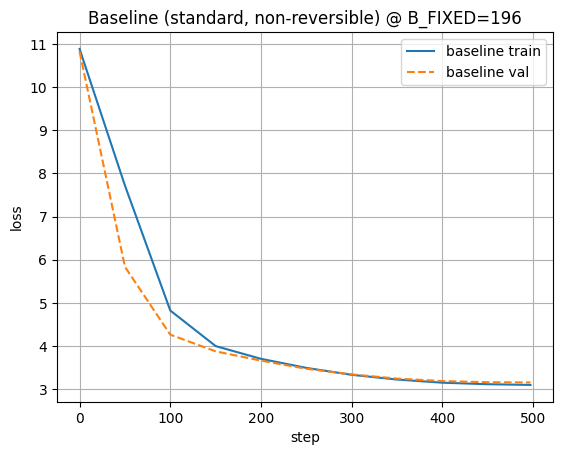

  probe batch=8 ...
  probe batch=16 ...
  probe batch=32 ...
  probe batch=64 ...
  probe batch=128 ...
  probe batch=256 ...
  probe batch=512 ...
  probe batch=1024 ...
  probe batch=768 ...
  probe batch=640 ...
  probe batch=576 ...
  probe batch=544 ...
  probe batch=528 ...
  probe batch=536 ...
  probe batch=540 ...
  probe batch=538 ...
  probe batch=537 ...
B_MAX[baseline] = 537

B_FIXED = 196 | B_MAX[baseline] = 537
memory breakdown @ B=16,T=128: params 80.4 MB | stack-only fwd+bwd 737.8 MB | full (stack+head+CE) 937.4 MB


In [6]:
import json

train_arr, val_arr = load_data()
print(f"train tokens: {len(train_arr):,}  |  val tokens: {len(val_arr):,}")
config = GPTConfig(block_size=BLOCK_SIZE)

# --- Baseline: train at the shared equal-batch anchor B_FIXED ---
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
model = GPT(config).to(device)
print(f"params: {model.num_parameters()/1e6:.2f}M")
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1, betas=(0.9, 0.95))
summary_b, hist_b = train(model, opt, B_FIXED, TOKENS, BLOCK_SIZE, LR, train_arr, val_arr,
                          rng, device, USE_AMP, CE_CHUNKS, "baseline", variant="standard")
print(json.dumps(summary_b, indent=2))
show_results([summary_b], [hist_b], f"Baseline (standard, non-reversible) @ B_FIXED={B_FIXED}")

# --- Context: the baseline's own maximum batch (for the memory story) ---
torch.manual_seed(SEED)
probe_rng = np.random.default_rng(SEED + 999)
probe = GPT(config).to(device)
probe_opt = torch.optim.AdamW(probe.parameters(), lr=LR)
B_MAX_BASE = find_max_batch(probe, probe_opt, train_arr, BLOCK_SIZE, probe_rng,
                            device, USE_AMP, CE_CHUNKS)
print(f"B_MAX[baseline] = {B_MAX_BASE}")
del probe, probe_opt
if device.type == "cuda":
    torch.cuda.empty_cache()

print(f"\nB_FIXED = {B_FIXED} | B_MAX[baseline] = {B_MAX_BASE}")

# --- Where does the memory go? (params / stack activations / vocab head) ---
torch.manual_seed(SEED)
model_bd = GPT(config).to(device)
memory_breakdown(model_bd)
del model_bd


## 6. Baseline at its own maximum batch

A second baseline model is trained at the probed `B_MAX` over the same 50M-token
budget. Because `total_steps = tokens // (B·T)`, this run takes fewer optimizer
steps than the `B_FIXED` run; it is a memory/throughput datapoint, not a quality
comparison.

step     0/181 | loss 10.8839 | val 10.7315 | tok/s 17902 | mem 41551MB
step    25/181 | loss 9.2562 | val 10.7315 | tok/s 78470 | mem 41712MB
step    50/181 | loss 7.0976 | val 5.6014 | tok/s 77412 | mem 41712MB
step    75/181 | loss 5.6704 | val 5.6014 | tok/s 81421 | mem 41712MB
step   100/181 | loss 4.8530 | val 4.4217 | tok/s 80025 | mem 41712MB
step   125/181 | loss 4.4239 | val 4.4217 | tok/s 81305 | mem 41712MB
step   150/181 | loss 4.2190 | val 4.1561 | tok/s 80056 | mem 41712MB
step   175/181 | loss 4.1390 | val 4.1561 | tok/s 81179 | mem 41712MB
step   180/181 | loss 4.1292 | val 4.1415 | tok/s 79783 | mem 41712MB
{
  "run": "baseline@B_MAX",
  "params_M": 20.11,
  "batch_size": 537,
  "micro_batch": 537,
  "grad_accum_steps": 1,
  "block_size": 512,
  "tokens": 49764864,
  "total_steps": 181,
  "warmup_steps": 18,
  "final_train_loss": 4.1292,
  "final_train_loss_last_batch": 4.0873,
  "final_val_loss": 4.1415,
  "avg_tok_per_sec": 79783.4,
  "peak_tok_per_sec": 109112.3,
 

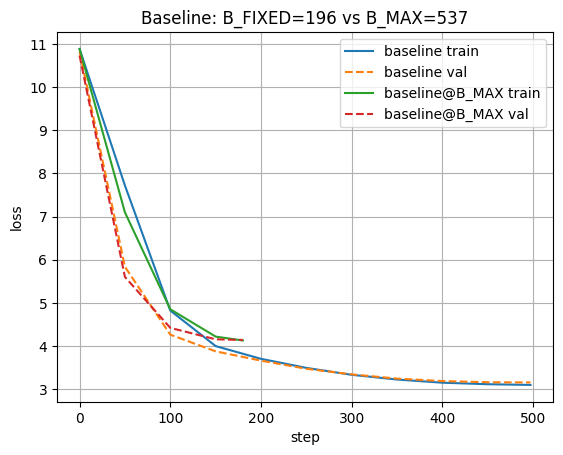


baseline  B_FIXED=196 (val 3.1565) | B_MAX=537 (val 4.1415)


In [7]:
# --- Baseline at its OWN maximum batch (same 50M-token budget) ---
# Run this cell AFTER the previous training cell in the SAME session, so that
# `config`, `train_arr`, `val_arr`, `summary_b`, `hist_b` and `B_MAX_BASE` exist.
# It is the baseline @ B_MAX datapoint: same protocol/token budget as every other
# run, so its lower step count (tokens // (B_MAX*T)) makes it a memory/throughput
# comparison rather than a quality one.
import json

torch.manual_seed(SEED)
rng_max = np.random.default_rng(SEED)
model_max = GPT(config).to(device)
opt_max = torch.optim.AdamW(model_max.parameters(), lr=LR, weight_decay=0.1, betas=(0.9, 0.95))
summary_bmax, hist_bmax = train(model_max, opt_max, B_MAX_BASE, TOKENS, BLOCK_SIZE, LR,
                                train_arr, val_arr, rng_max, device, USE_AMP, CE_CHUNKS,
                                "baseline@B_MAX", variant="standard", B_MAX=B_MAX_BASE)
print(json.dumps(summary_bmax, indent=2))
show_results([summary_b, summary_bmax], [hist_b, hist_bmax],
             f"Baseline: B_FIXED={B_FIXED} vs B_MAX={B_MAX_BASE}")
print(f"\nbaseline  B_FIXED={B_FIXED} (val {summary_b['final_val_loss']:.4f}) | "
      f"B_MAX={B_MAX_BASE} (val {summary_bmax['final_val_loss']:.4f})")


## 7. Observations from Experiment 1

- The standard stack peaks at **15,313 MB** at `B_FIXED = 196` and at
  **41,712 MB** at its own maximum (`B_MAX = 537`). Throughput falls from
  **145,042** to **79,783 tokens/s** as the run approaches the device limit
  (~97% of VRAM), i.e. a memory-bound regime.
- At `B_FIXED` the vocabulary head dominates the equal-batch peak; the stack
  activations account for the difference between the two models.
- The probed non-reversible maximum of **537** sets the reference against which
  the reversible max-batch results in Experiments 2-4 are compared.
- Final val loss: **3.1565** at `B_FIXED`.